In [1]:
from shapely.geometry import shape
import json
import pandas as pd
from scipy.signal import detrend
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [2]:
PID_df=pd.read_csv('data/lookup/PID_location_all.csv')
csc_df= pd.read_csv('data/processed/PID_csc_upsampled.csv')
# npp_df = pd.read_csv('data/processed/npp_tac.csv')
npp_df=pd.read_csv('data/processed/PID_npp.csv')


In [3]:
npp_df.drop(columns=(['Unnamed: 0']), inplace=True)

In [4]:
PID_df["managed"] = PID_df["managed"].fillna(-1)
PID_df["ownership"] = PID_df["ownership"].fillna("No Data")
PID_df["biome"] = PID_df["biome"].fillna("No Data")
PID_df = PID_df[PID_df["lon"] <= 0]
PID_df = PID_df[PID_df["lat"] > 22]

In [5]:
csc_df.rename(columns={'PID_left': "PID"}, inplace= True)
csc_df.drop(columns=['Unnamed: 0'], inplace=True)

csc_df=csc_df.merge(PID_df, on='PID', how='inner')

## Preprocessing 


In [ ]:
def autocorr_pid(group, max_lag=1):
    group = group.sort_values('year')
    acfs = [group['Npp'].autocorr(lag=1)]
    return pd.Series(acfs, index=[f'ACF_lag{lag}' for lag in range(1, max_lag+1)])

def detrend_pid(group):
    # Sort by year
    group = group.sort_values('year')
    # Detrend NPP
    group['NPP_detrended'] = detrend(group['Npp'].values)
    return group

def compute_residuals(group):
    X = group["year"].values.reshape(-1,1)
    y = group["Npp"].values
    
    model = LinearRegression().fit(X, y)
    y_hat = model.predict(X)
    
    group["transformed npp"] = y - y_hat
    return group

In [ ]:
# autocorr_df = npp_df.groupby('PID').apply(autocorr_pid).reset_index() # TAC LAG 1 autocorrelation
autocorr_df = npp_df.groupby("PID", group_keys=False).apply(compute_residuals) # Residuals 
df= autocorr_df[["PID", "transformed npp"]]


In [12]:
autocorr_df

,PID,Npp,year,residual
0,1_32_3_760_420,0.1297,2014,-0.005312
1,1_32_3_760_420,0.1355,2015,0.000732
2,1_32_3_760_420,0.1245,2018,-0.009535
3,1_32_3_760_420,0.1407,2013,0.005444
4,1_32_3_760_420,0.1580,2017,0.023721
...,...,...,...,...
1241734,1_19_5_20090_1,0.6123,2011,-0.040614
1241735,1_19_5_20090_1,0.7198,2016,0.068035
1241736,1_19_5_20090_1,0.7095,2010,0.056356
1241737,1_19_5_20090_1,0.7108,2015,0.058805


In [14]:
df = df.rename(columns={"transformed npp": "TAC_NPP"})
# df_joined=df

total_df = df.merge(PID_df, on='PID', how='inner')
total_df.dropna(subset=["TAC_NPP"], inplace=True)

In [15]:
total_df.to_csv('data/processed/npp_tac.csv', index=False)

# Visualisations

### Looking at NPP Before Detrending 

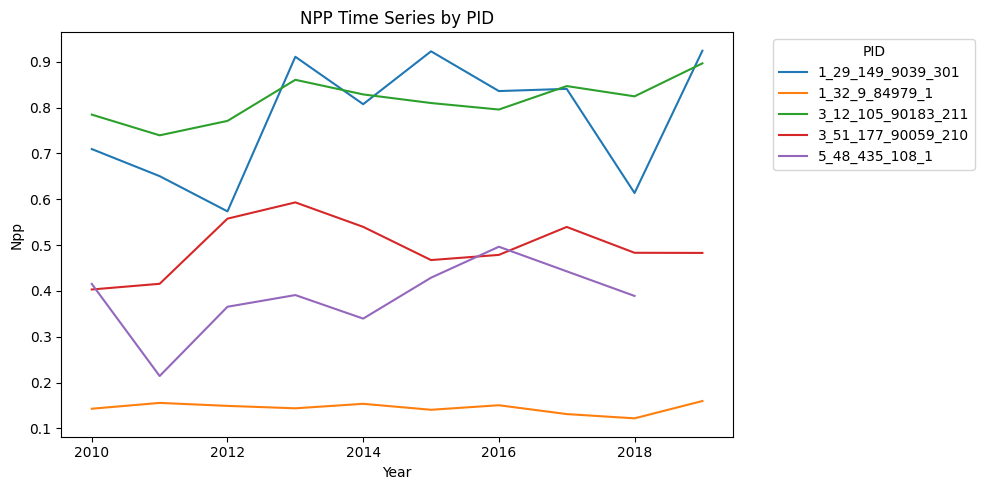

In [9]:
import matplotlib.pyplot as plt
sample_vals = npp_df["PID"].sample(5, replace=False)
filtered_df = npp_df[npp_df["PID"].isin(sample_vals)]
pid_codes = filtered_df["PID"].astype("category").cat.codes
plt.figure(figsize=(10,5))

for pid, g in filtered_df.groupby("PID"):
    g = g.sort_values("year")
    plt.plot(g["year"], g["Npp"], label=pid)

plt.xlabel("Year")
plt.ylabel("Npp")
plt.title("NPP Time Series by PID")
plt.legend(title="PID", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

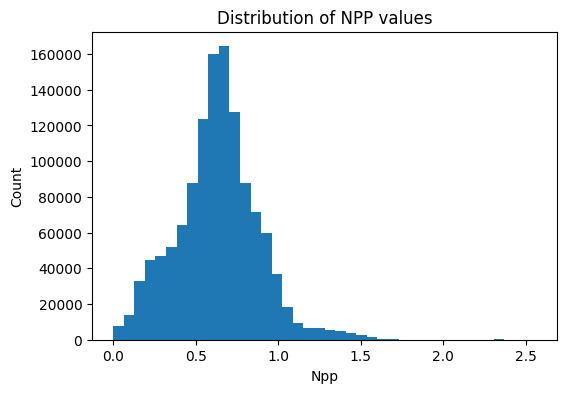

In [ ]:
title = "Distribution of NPP values"
x= "Npp"

plt.figure(figsize=(6,4))
plt.hist(npp_df[x], bins=40)
plt.xlabel(x)
plt.ylabel("Count")
plt.title(title)
plt.show()

### Spatial Analysis 

In [ ]:

# Assign a color to each forest type
forest_colors = {
    'Temperate conifer forests': 'lightgreen',
    'Temperate grasslands': 'lightblue',
    'Xeric shrublands': 'wheat',
    'Mediterranean woodlands': 'orange',
    'Tropical coniferous forests': 'darkgreen',
    'No Data': 'gray'
}

managed= {
    1.0: 'blue',
    0.0: 'red',
    -1.0: 'gray'
}

ownership = {
    'national_forest': 'darkblue',
    'other': 'lightgray',
    'state': 'lightgreen',
    'blm': 'orange',
    'national_park': 'darkgreen',
    'local': 'purple',
    'other_federal': 'brown',
    'fish_wildlife': 'pink',
    'dod': 'gray',
    'other_forest_service': 'lightblue',
    'national_grassland': 'yellow',
    'No Data': 'gray'

}


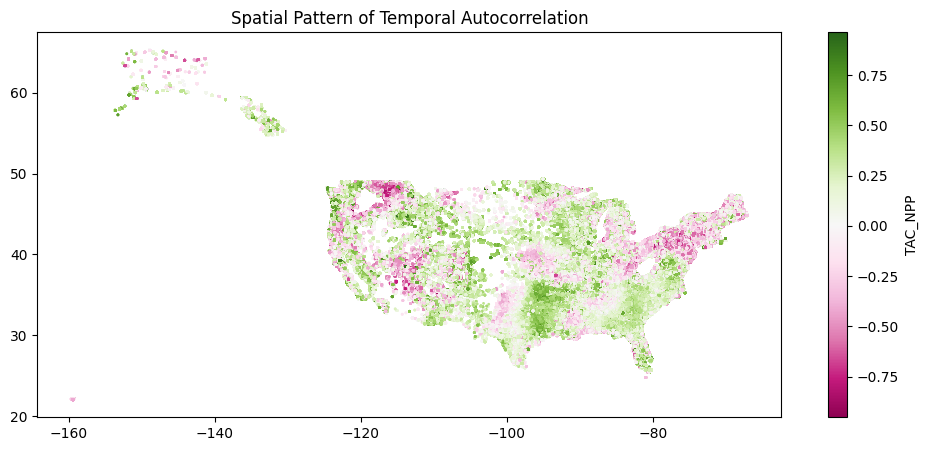

In [ ]:
npp_value = 'TAC_NPP'

plt.figure(figsize=(12,5))
plt.scatter(total_df["lon"], total_df["lat"], c=total_df[npp_value], s=1, cmap= 'PiYG')
plt.colorbar(label=npp_value)
plt.title(f"Spatial Pattern of  {npp_value}")
plt.show()

In [ ]:
count_A1 = ((total_df['managed'] == 1.0) & (total_df['TAC_NPP'] < 0)).sum()
counts = total_df['managed'].value_counts()
num_negative = (total_df['TAC_NPP'] < 0).sum()

print(f'number of managed forests {counts} and number of declining NPP<0: {num_negative} /n Number of managed forests with declining NPP<0:, {count_A1}')

Number of managed forests with declining NPP<0: 466491


In [ ]:
df_managed = total_df[total_df["managed"] == 1.0]

/tmp/ipykernel_1826000/1656914146.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


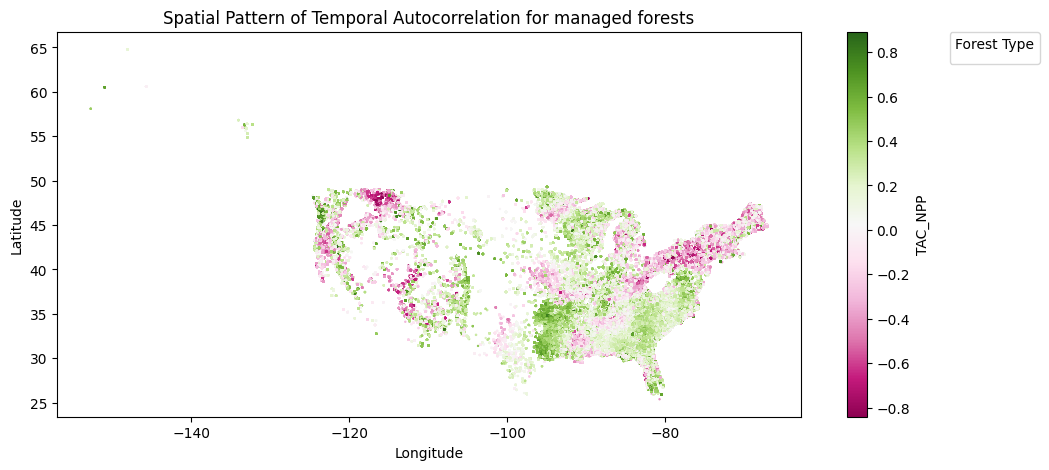

In [ ]:
plt.figure(figsize=(12,5))

sc = plt.scatter(
    df_managed["lon"], 
    df_managed["lat"], 
    c=df_managed["TAC_NPP"], 
    s=0.5, 
    cmap='PiYG'
)

plt.colorbar(sc, label="TAC_NPP")

plt.title("Spatial Pattern of Temporal Autocorrelation for managed forests")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Forest Type",
    bbox_to_anchor=(1.2, 1),  # x=1.05 moves it right outside axes
    loc='upper left',           # anchors the legend's upper-left corner
    borderaxespad=0            # padding between axes and legend
)
plt.show()


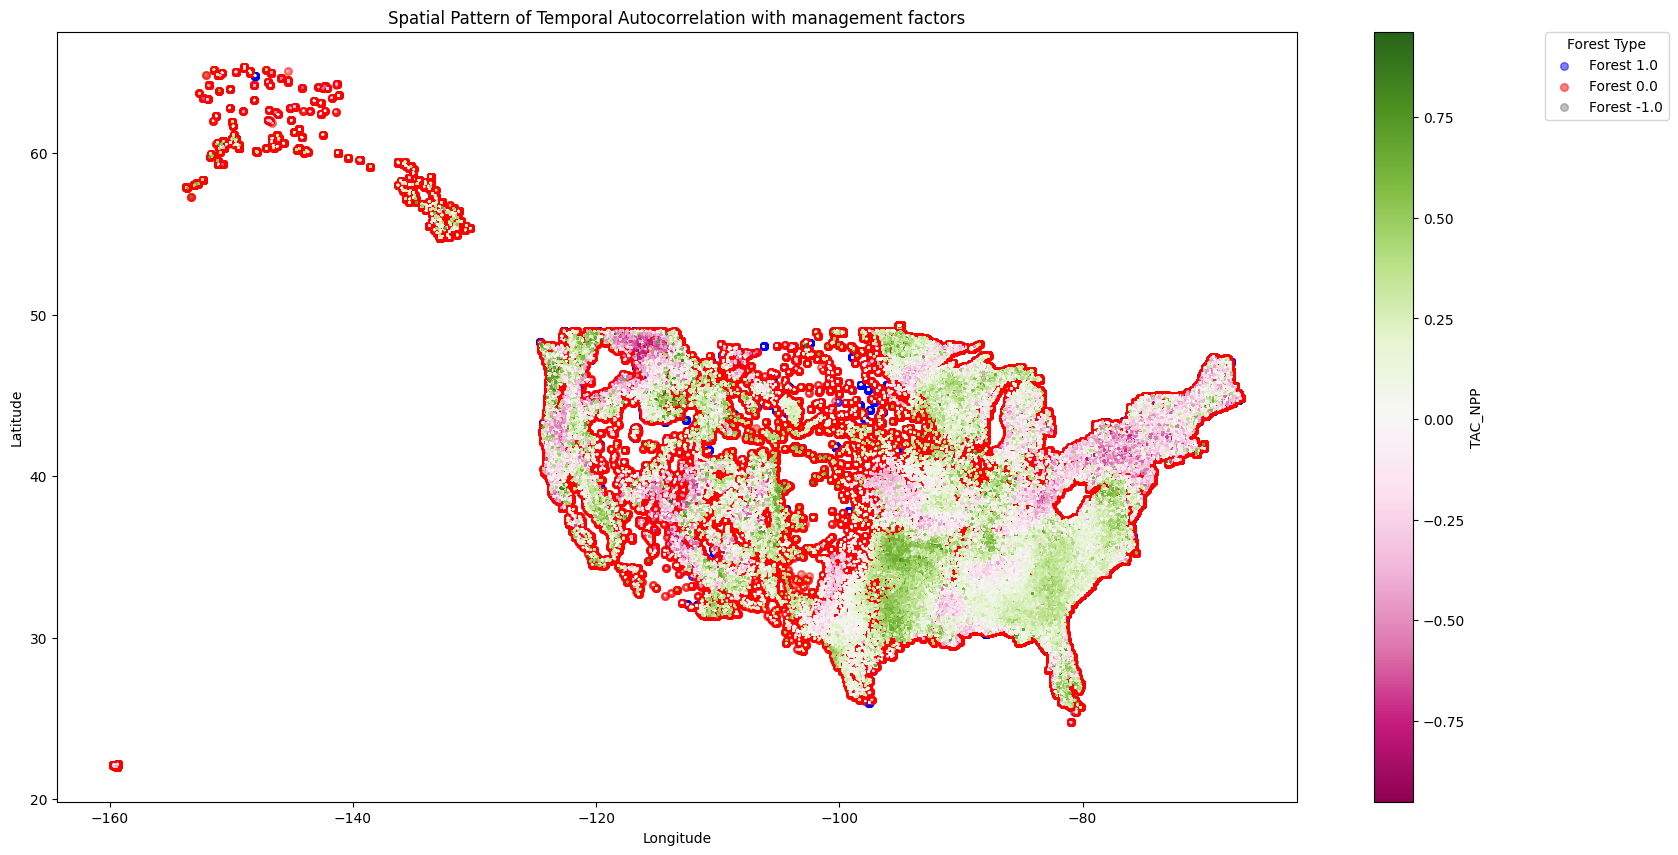

In [ ]:
plt.figure(figsize=(20,10))

for ftype, color in managed.items():
    subset = total_df[total_df["managed"] == ftype]
    plt.scatter(
        subset["lon"], 
        subset["lat"], 
        color=color, 
        alpha=0.5,  # transparency
        s=30, 
        label=f"Forest {ftype}"
    )

# First, scatter points colored by TAC_NPP
sc = plt.scatter(
    total_df["lon"], 
    total_df["lat"], 
    c=total_df["TAC_NPP"], 
    s=0.5, 
    cmap='PiYG'
)
plt.colorbar(sc, label="TAC_NPP")

plt.title("Spatial Pattern of Temporal Autocorrelation with management factors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Forest Type",
    bbox_to_anchor=(1.2, 1),  # x=1.05 moves it right outside axes
    loc='upper left',           # anchors the legend's upper-left corner
    borderaxespad=0            # padding between axes and legend
)
plt.show()

### Canopy Complexity 

In [ ]:
csc_df.rename(columns={'PID_left': "PID"}, inplace= True)
csc_df.drop(columns=['Unnamed: 0'], inplace=True)

csc_df=csc_df.merge(PID_df, on='PID', how='inner')

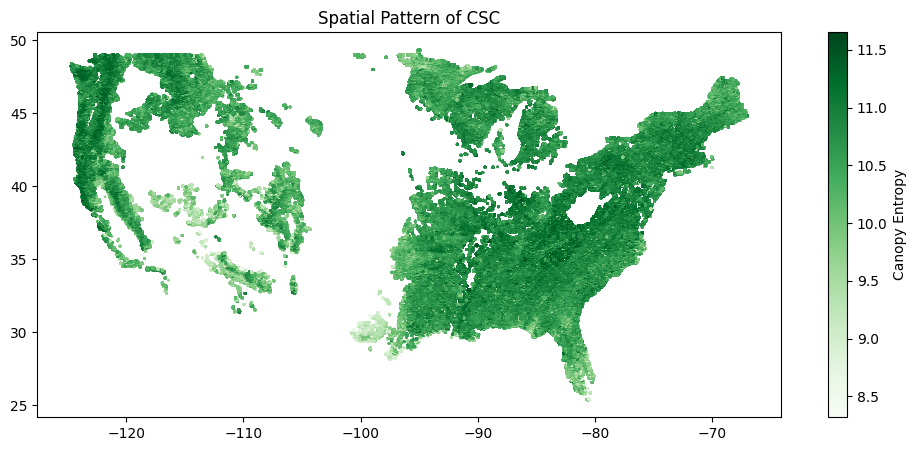

In [15]:
plt.figure(figsize=(12,5))
plt.scatter(csc_df["lon"], csc_df["lat"], c=csc_df["csc"], s=1, cmap= 'Greens')
plt.colorbar(label="Canopy Entropy")
plt.title("Spatial Pattern of CSC")
plt.show()

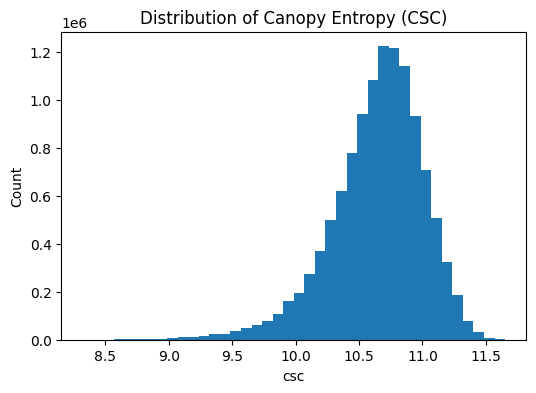

In [17]:

title = "Distribution of Canopy Entropy (CSC)"
x= "csc"

plt.figure(figsize=(6,4))
plt.hist(csc_df[x], bins=40)
plt.xlabel(x)
plt.ylabel("Count")
plt.title(title)
plt.show()


## Stability Metric v1

This version of stability is Stability = TAC LAG 1 (NPP) + min_max scaled (csc)

In [2]:
from shapely.geometry import shape
import json
import pandas as pd
from scipy.signal import detrend
import geopandas as gpd
import pandas as pd

In [3]:
csc_df= pd.read_csv('data/processed/PID_csc_upsampled.csv')
npp_df = pd.read_csv('data/processed/npp_tac.csv')


In [4]:
csc_df.rename(columns={'PID_left': "PID"}, inplace= True)
csc_df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
merged_df = npp_df.merge(csc_df, on='PID', how='left', suffixes=('_','_orig'))
merged_df = merged_df.drop(columns=[col for col in merged_df.columns if "orig" in col])
merged_df.dropna(subset=['csc', 'TAC_NPP'], inplace=True)

normalized = (merged_df['csc']-min(merged_df['csc']))/(max(merged_df['csc'])-min(merged_df['csc']))
merged_df['Stability metric'] = normalized + abs(merged_df["TAC_NPP"])
merged_df["BHAGE"] = merged_df["BHAGE"].fillna("0.0")


In [ ]:
merged_df["abs_TAC_NPP"] = abs(merged_df["TAC_NPP"]) # Suggestion of ABS VALUE

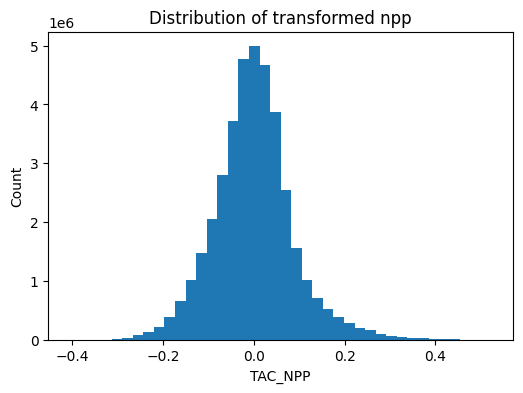

In [7]:
title = "Distribution of transformed npp"
x= "TAC_NPP"

plt.figure(figsize=(6,4))
plt.hist(merged_df[x], bins=40)
plt.xlabel(x)
plt.ylabel("Count")
plt.title(title)
plt.show()

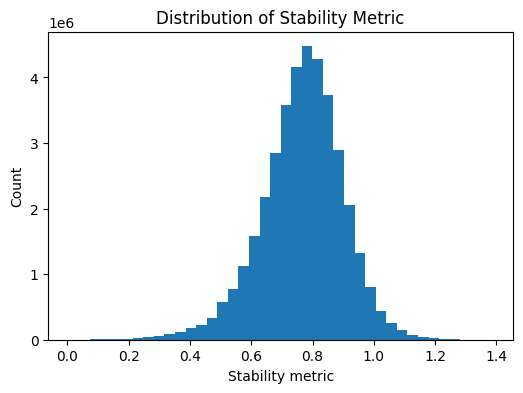

In [8]:
title = "Distribution of Stability Metric"
x= "Stability metric"

plt.figure(figsize=(6,4))
plt.hist(merged_df[x], bins=40)
plt.xlabel(x)
plt.ylabel("Count")
plt.title(title)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import box

# Pink → white → green
cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#F40D0D", "#CADDD6", "#075706"]  # pink, zero, positive
)

norm = mcolors.TwoSlopeNorm(
    vmin=merged_df['Stability metric'].min(),
    vcenter=0.2,
    vmax=merged_df["Stability metric"].max()
)

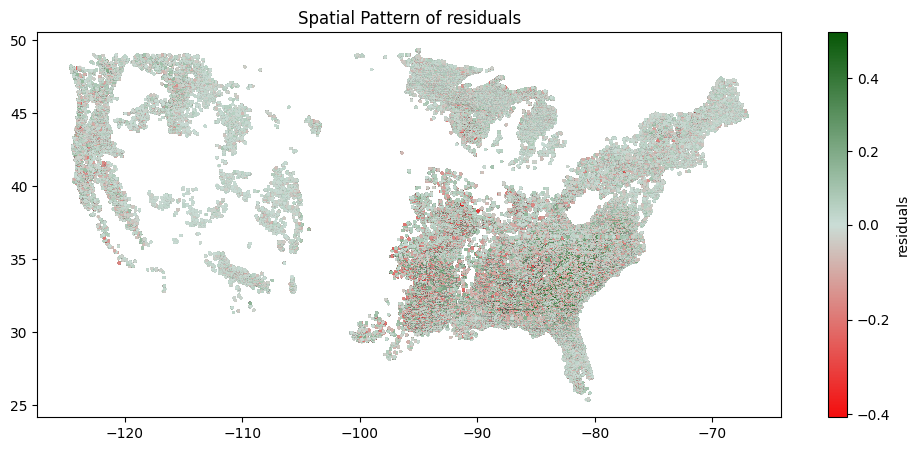

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(merged_df["lon"], merged_df["lat"], c=merged_df["Stability metric" ], s=1, cmap='RdYlGn', norm=norm)
plt.colorbar(label="Stability Metric")
plt.title("Spatial Pattern of our Stability Metric")
plt.show()

In [6]:
count_A1 = ((merged_df['managed'] == 1.0) & (merged_df['Stability metric'] < 0.2)).sum()
print("Number of managed forests with declining NPP<0:", count_A1)

counts = merged_df['managed'].value_counts()
num_negative = (merged_df['Stability metric'] < 0.2).sum()

print(f'number of managed forests{counts} and number of declining NPP<0: {num_negative}')

Number of managed forests with declining NPP<0: 13473
number of managed forestsmanaged
0.0    2472709
1.0    1327170
Name: count, dtype: int64 and number of declining NPP<0: 68252


In [19]:
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")
ecoregions = ecoregions.to_crs("EPSG:4326")

bbox = (-170, 5, -50, 85)
crop_box = box(*bbox)

na_ecoregions = ecoregions[ecoregions.intersects(crop_box)].copy()

del ecoregions

In [20]:
na_ecoregions.columns

Index(['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM',
       'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME',
       'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry'],
      dtype='object')

In [17]:
# Add in a subset
subset= merged_df[merged_df["Stability metric"] <= 0.5]

gdf1 = gpd.GeoDataFrame(
    subset,
    geometry=gpd.points_from_xy(subset["lon"], subset["lat"]),
    crs="EPSG:4326"  # WGS84
)

In [25]:
gdf = gpd.GeoDataFrame(
    merged_df,
    geometry=gpd.points_from_xy(merged_df["lon"], merged_df["lat"]),
    crs="EPSG:4326"  # WGS84
)

In [ ]:
gdf.columns

In [ ]:
import matplotlib.pyplot as plt
# Load the shapefile

ax = na_ecoregions.plot(
    color=na_ecoregions['COLOR_BIO'],  # or use a column like 'ECO_NAME'
    edgecolor='grey',
    figsize=(12,8)
)

gdf.plot(
    ax=ax,
    column="Stability metric",
    cmap='PiYG',
    markersize=0.5,
    alpha=0.2)

# Zoom to North America
ax.set_xlim(-140, -60)  # longitude
ax.set_ylim(20, 53)      # latitude

plt.show()

KeyboardInterrupt: 

## Stability Metric v2